# One-dimensional Forward Modeling
The most simple forward modeling problem is the calculation of the SQUID signal generated by a current running in an infinitely long strip. While this might seem oversimplified, modeling this the starting point for th eexperimental determinatin of current flow patterns, such as in the prototypical investigations of Poisueille flow in electron hydrodynamics.

We consider a SQUID sensor of inner radius $\rho_1$ and outer radius $\rho_2$ placed at a height $h$ above the sample. Mind that this is the distance between the SQUID center and the sample, not the tip-sample distance. The SQUID is tilted by an angle $\phi$ with respect to the surface normal such that a $\phi=0$ SQUID records only out-of-plane field, and a $\phi=\pi/2$ SQUID records only in-plane field. We use the following coordinate system:

![Coordinate systems used to describe the current imaging geometry.](illustrations/OrientationFigure.svg)

Here, current flows along a strip of width $W$ that is tilted an angle $\gamma$ with respect of the SQUID frame. The tilted frame is indicated with two primes $(x'',y'')$ and, since the strip is infinitely long, the current density is described by a function $\mathbf{J}=J(y'') \hat{\mathbf{x}}''$.

To perform forward modeling, we must import sottools.forward as well as numpy and matplotlib for numerical calculations and plotting, respectively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sottools.forward as forward

In SOTtools, forward calculations are performed by objects (e.g. of the Forward1D class) that are initialized with the geometry of the problem. This allows them to pre-compute all relevant kernels, and then perform the actual forward calculation for any current distribution in a very efficient manner. Generally, for simple forward problems, it is completely unneccesary to run on GPU. To parameterize these geometries, we use the Forward1DParameters class, which encapsulates the geometry of both the SQUID and the sample.

In [2]:
params = forward.Forward1DParameters(
    Lscan = 10.0, # Scan length in microns
    Wdevice = 5.0, # Device (strip) width
    Nscan = 256, # Number of points in the SQUID scan
    gamma = 0.0,
    rho1 = 0.2,
    rho2 = 0.4,
    height = 0.5,
    phi = np.deg2rad(63.0), # Standard TM-SOT sensor tilt angle
    invert_normal=True # Sets the sign of the SQUID response
)

fwd = forward.Forward1D(params)

A small note on units: standard SOTtools is configured to be used in units of micrometers, micro-amps and microteslas. To change the unit system, one can pass a value for the vacuum permittivity $\mu_0$ to the Forward1D constructor. For instance, passing $4\pi \cdot 10^{-7}$ will set the units to SI (meters, amps, teslas).

The sottools.utils classes contain various utility functions for plotting and visualization. For instance, we can use it to calculate the kernel of the forward problem. The kernel shows the SQUID response to a delta function (one grid point wide) of current in the middle of the device. Note that the kernel is given in arbitrary units.

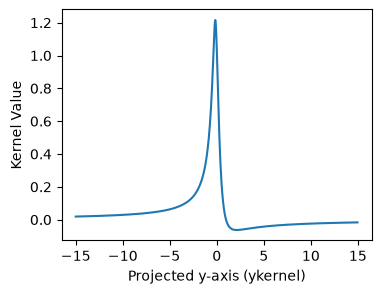

In [3]:
import sottools.utils.forwardplotting as forwardplotting
fig, ax = plt.subplots(1,1,figsize=(4,3))
forwardplotting.plot_1dforwardkernel(fwd, ax)
plt.show()

The horizontal axis has a total width of $30=3\times L_{scan}$. This is deliberate: SOTtools zero-pads current distributions to three times the scan length and then uses a wider kernel, to avoid any edge effects whatsoever.

Using our fwd object, we can now calculate the SQUID response to any current distribution. For instance, we can calculate the response to two edge currents.

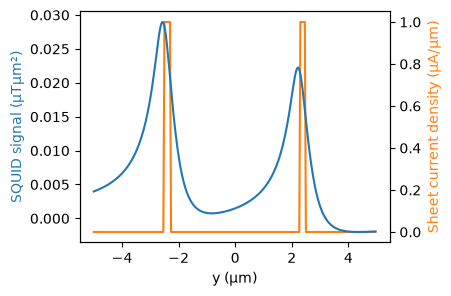

In [16]:
channelwidth = 0.2 # Width of the edge channels
ydevice = params.ydevice.cpu().numpy() # Convert to NumPy from Torch
yscan = params.yscan.cpu().numpy() # Convert to NumPy from Torch
currents = np.zeros_like(ydevice)
currents[(ydevice < -params.Wdevice/2 + channelwidth) | (ydevice > params.Wdevice/2 - channelwidth)] = 1.0

signal = fwd.forward(currents)

# For plotting esthetics, we embed currents in a zero-padded array of length Lscan
currents_plotting = np.zeros_like(yscan)
Nscan = len(yscan)
Ndevice = len(ydevice)
currents_plotting[Nscan//2-Ndevice//2:Nscan//2+Ndevice//2] = currents

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax_current = ax.twinx()
ax_current.plot(yscan, currents_plotting, color='C1')
ax.plot(yscan, signal, color='C0')
ax.set_zorder(ax_current.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_xlabel('y (µm)')
ax.set_ylabel('SQUID signal (µTµm²)', color='C0')
ax_current.set_ylabel('Sheet current density (µA/µm)', color='C1')
plt.show()